In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("C:/Users/hp/OneDrive/Desktop/Fraud Detection/data/credit_card_fraud_10k.csv")

In [3]:
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [4]:
df.shape

(10000, 10)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  str    
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), str(1)
memory usage: 781.4 KB


In [6]:
df.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


In [7]:
df.isnull().sum()

transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

# Exploratory Data Analysis

In [8]:
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


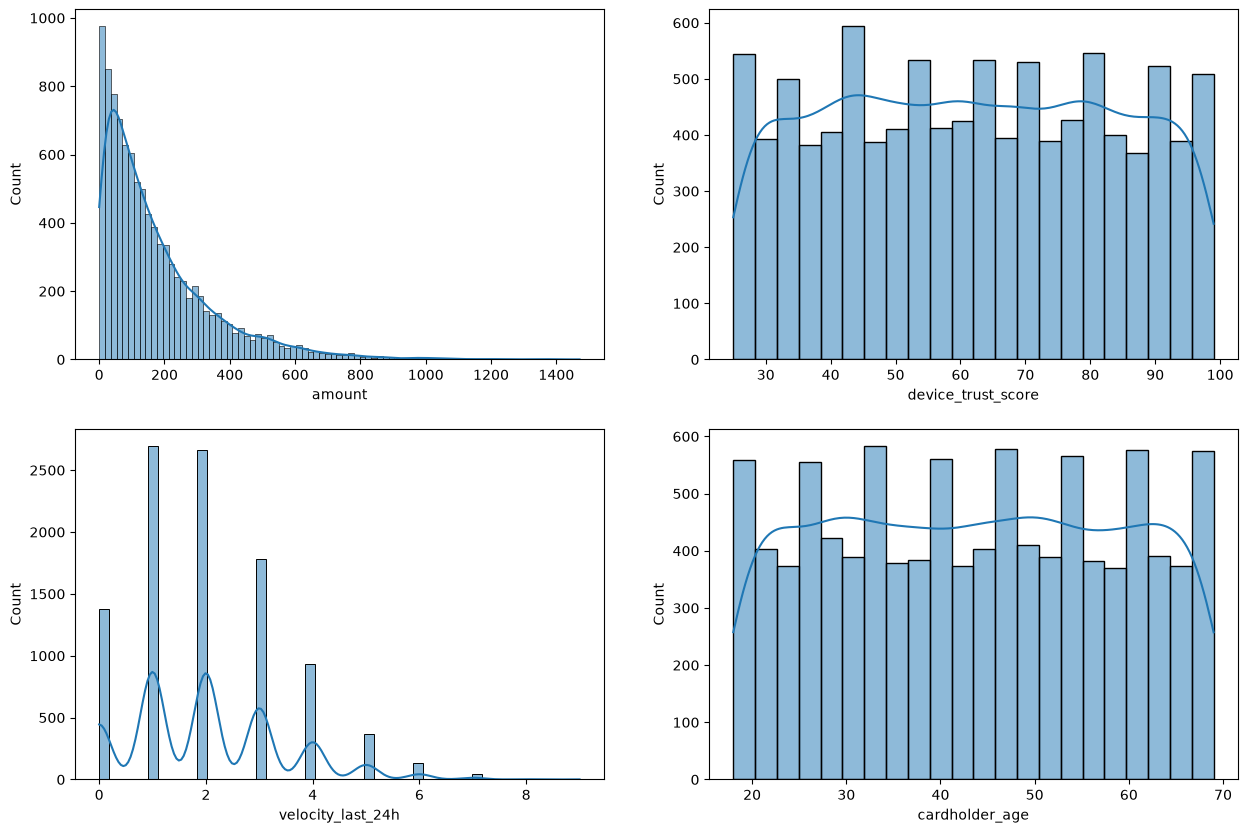

In [9]:
# Univariate Analysis
cols=['amount','device_trust_score','velocity_last_24h','cardholder_age']

plt.figure(figsize=(15,10))
for i, col in enumerate(cols):
    plt.subplot(2,2,i+1)
    sns.histplot(data=df,x=col,kde=True)

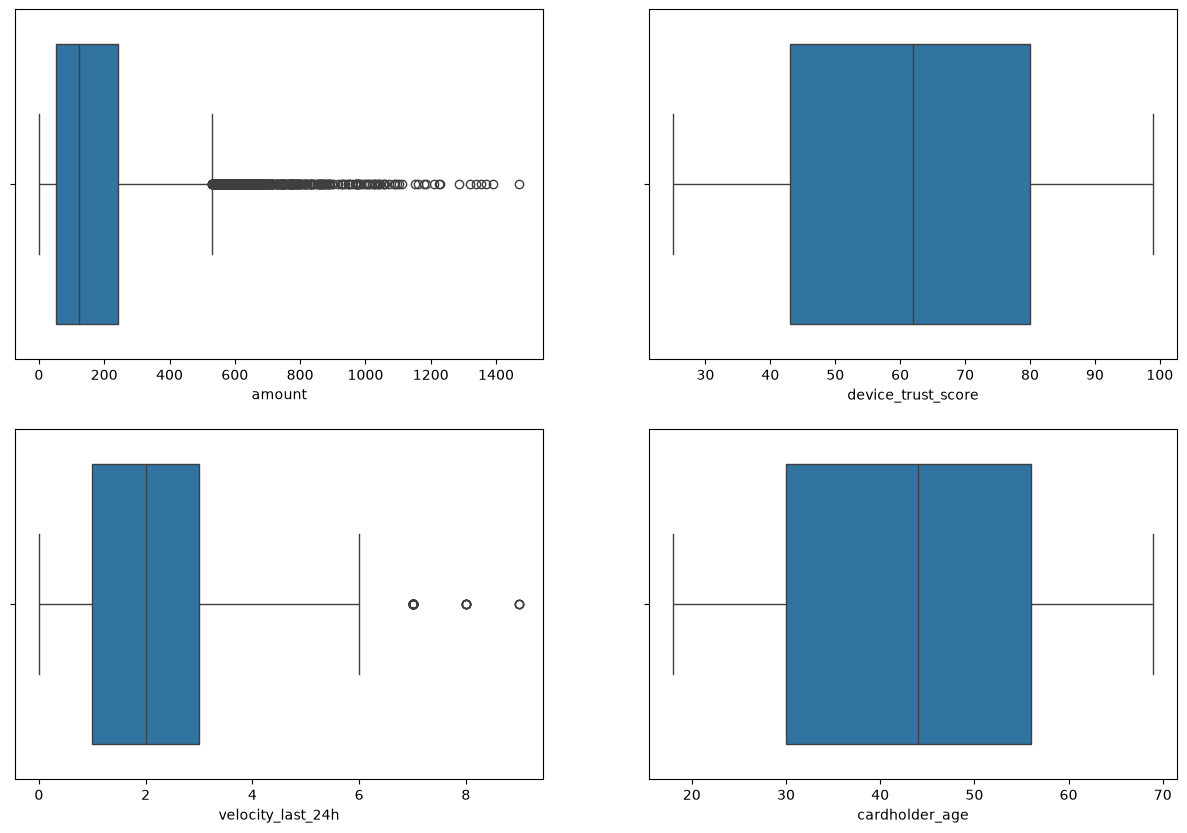

In [10]:
## Outliers Check
cols=['amount','device_trust_score','velocity_last_24h','cardholder_age']

plt.figure(figsize=(15,10))
for i, col in enumerate(cols):
    plt.subplot(2,2,i+1)
    sns.boxplot(data=df,x=col,)

<Axes: xlabel='merchant_category', ylabel='count'>

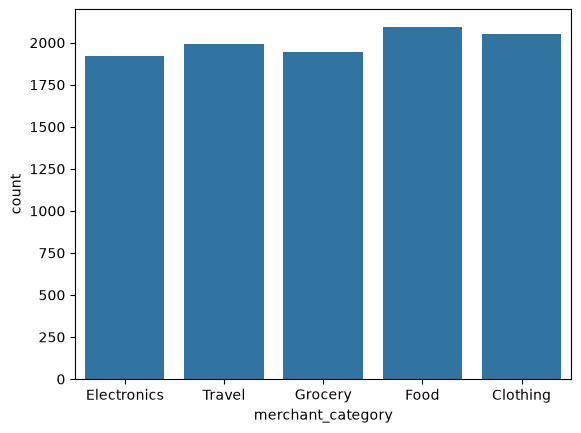

In [11]:
sns.countplot(data=df,x='merchant_category')

In [12]:
## Bivariate Analysis

In [13]:
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


<Axes: xlabel='merchant_category', ylabel='amount'>

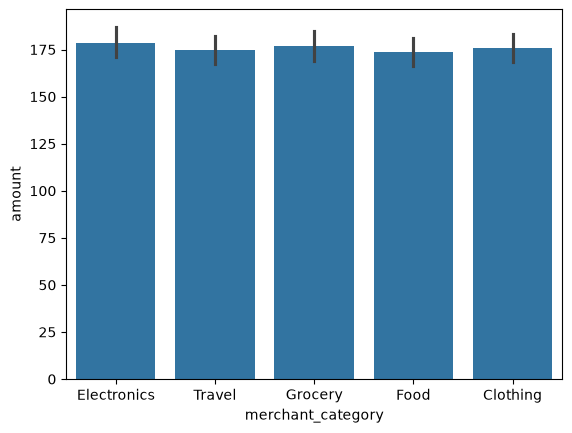

In [14]:
sns.barplot(data=df,x='merchant_category',y='amount')

<Axes: xlabel='transaction_hour', ylabel='amount'>

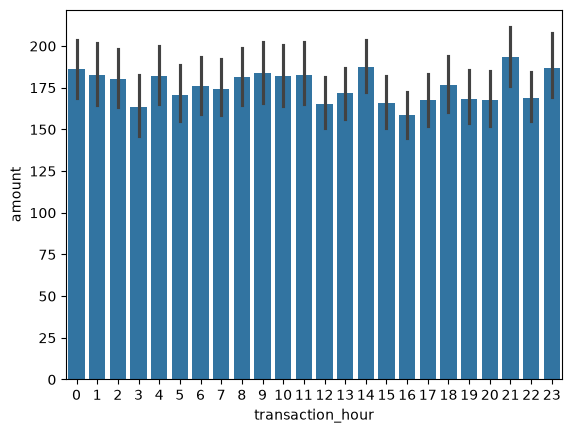

In [15]:
sns.barplot(data=df,x='transaction_hour',y='amount')

In [16]:
df.columns

Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='str')

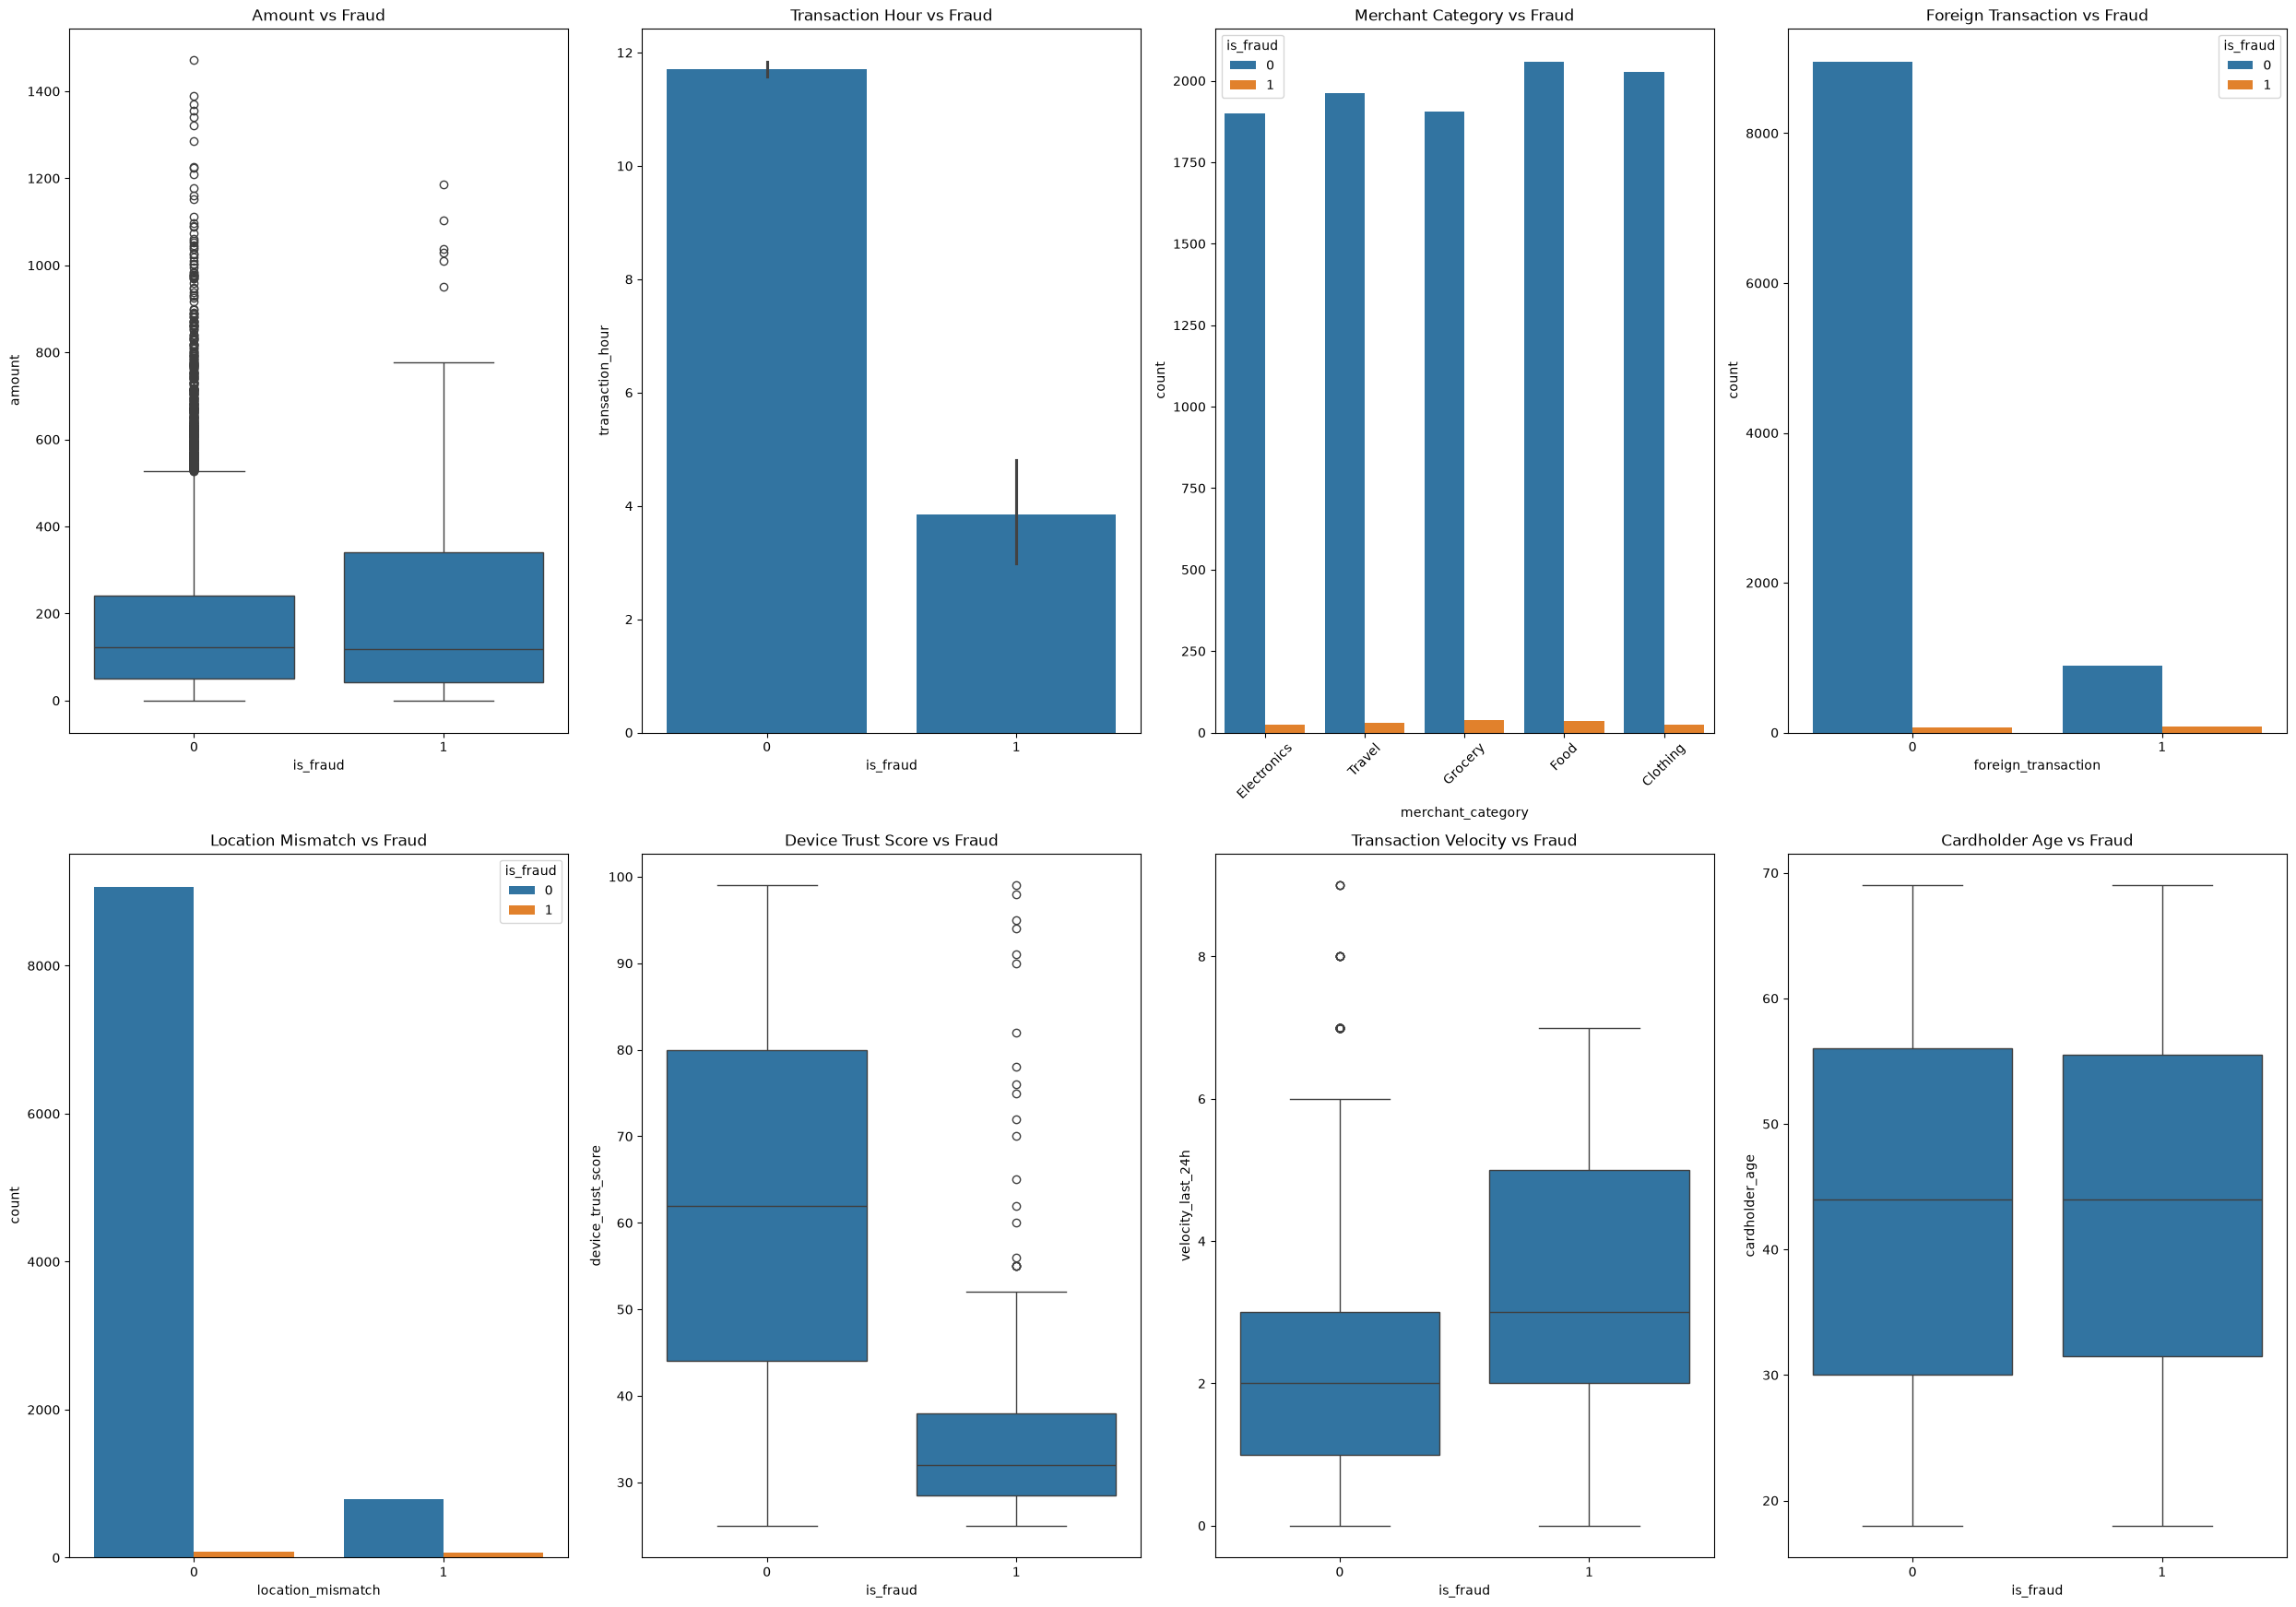

In [17]:
plt.figure(figsize=(25, 35))

plt.subplot(4, 4, 1)
sns.boxplot(data=df, x='is_fraud', y='amount')
plt.title('Amount vs Fraud')

plt.subplot(4, 4, 2)
sns.barplot(data=df, x='is_fraud', y='transaction_hour')
plt.title('Transaction Hour vs Fraud')

plt.subplot(4, 4, 3)
sns.countplot(data=df, x='merchant_category', hue='is_fraud')
plt.title('Merchant Category vs Fraud')
plt.xticks(rotation=45)

plt.subplot(4, 4, 4)
sns.countplot(data=df, x='foreign_transaction', hue='is_fraud')
plt.title('Foreign Transaction vs Fraud')

plt.subplot(4, 4, 5)
sns.countplot(data=df, x='location_mismatch', hue='is_fraud')
plt.title('Location Mismatch vs Fraud')

plt.subplot(4, 4, 6)
sns.boxplot(data=df, x='is_fraud', y='device_trust_score')
plt.title('Device Trust Score vs Fraud')

plt.subplot(4, 4, 7)
sns.boxplot(data=df, x='is_fraud', y='velocity_last_24h')
plt.title('Transaction Velocity vs Fraud')

plt.subplot(4, 4, 8)
sns.boxplot(data=df, x='is_fraud', y='cardholder_age')
plt.title('Cardholder Age vs Fraud')

plt.tight_layout()
plt.show()

In [18]:
## percentage value of fraud as per merchant category
hm=pd.crosstab(
    df['merchant_category'],
    df['is_fraud'],
    normalize='index'
) * 100

In [19]:
hm

is_fraud,0,1
merchant_category,,
Clothing,98.829268,1.170732
Electronics,98.751950,1.248050
Food,98.327759,1.672241
Grocery,97.993827,2.006173
Travel,98.542714,1.457286


<Axes: xlabel='is_fraud', ylabel='merchant_category'>

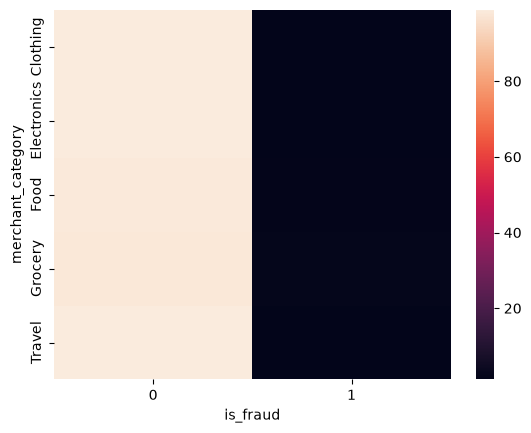

In [20]:
sns.heatmap(hm)

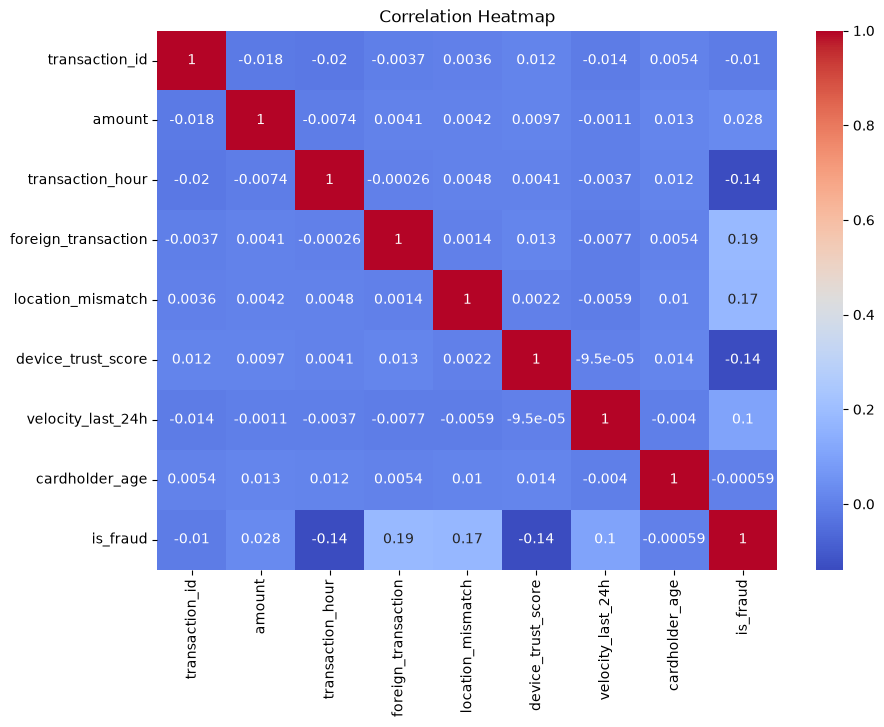

In [21]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

# Feature Engineering

In [22]:
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [23]:
df=df[['amount','transaction_hour','merchant_category','foreign_transaction','location_mismatch','device_trust_score','velocity_last_24h','cardholder_age','is_fraud']]

In [24]:
## Separating independant and dependant variable
X=df[['amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age']]
Y=df['is_fraud']

In [25]:
## train_test_split
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

In [26]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nY_train:")
print(Y_train.value_counts())

print("\nY_test:")
print(Y_test.value_counts())

X_train: (8000, 8)
X_test: (2000, 8)

Y_train:
is_fraud
0    7879
1     121
Name: count, dtype: int64

Y_test:
is_fraud
0    1970
1      30
Name: count, dtype: int64


In [27]:
numeric_features = [
    'amount',
    'transaction_hour',
    'device_trust_score',
    'velocity_last_24h',
    'cardholder_age'
]

In [28]:
categorical_features = [
    'merchant_category'
]

In [29]:
## Encoding and scaling through ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor=ColumnTransformer(
    transformers=[('mun',StandardScaler(),numeric_features),
                ('cat',OneHotEncoder(handle_unknown='ignore'),categorical_features)],
                remainder='passthrough'
                )

In [30]:
X_train_processed=preprocessor.fit_transform(X_train)
X_test_processed=preprocessor.transform(X_test)

In [31]:
## Checking the result
print(X_train_processed.shape)
print(X_test_processed.shape)

(8000, 12)
(2000, 12)


# Training the model

### LogisticRegression

In [32]:
from sklearn.linear_model import LogisticRegression

lr=LogisticRegression(class_weight='balanced',random_state=42,max_iter=1000)
lr.fit(X_train_processed,Y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [33]:
y_pred=lr.predict(X_test_processed)

In [34]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1970
           1       0.26      1.00      0.41        30

    accuracy                           0.96      2000
   macro avg       0.63      0.98      0.70      2000
weighted avg       0.99      0.96      0.97      2000



In [35]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, y_pred)

print(cm)

[[1885   85]
 [   0   30]]


In [36]:
from sklearn.metrics import roc_auc_score

y_probability = lr.predict_proba(X_test_processed)[:, 1]

roc_auc = roc_auc_score(Y_test, y_probability)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9933333333333333


### RandomForestClassifier

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(n_estimators=200,class_weight='balanced',random_state=42,n_jobs=-1)
rf.fit(X_train_processed,Y_train)
y_pred=rf.predict(X_test_processed)

In [38]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      0.83      0.91        30

    accuracy                           1.00      2000
   macro avg       1.00      0.92      0.95      2000
weighted avg       1.00      1.00      1.00      2000



In [39]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(Y_test,y_pred))

[[1970    0]
 [   5   25]]


In [40]:
from sklearn.metrics import roc_auc_score

y_probability = rf.predict_proba(X_test_processed)[:, 1]

roc_auc = roc_auc_score(Y_test, y_probability)

print("ROC-AUC:", roc_auc)

ROC-AUC: 1.0


### DecisionTreeClassifier

In [41]:
from sklearn.tree import DecisionTreeClassifier

dtc=DecisionTreeClassifier(class_weight='balanced')
dtc.fit(X_train_processed,Y_train)
y_pred=dtc.predict(X_test_processed)

In [42]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       0.97      1.00      0.98        30

    accuracy                           1.00      2000
   macro avg       0.98      1.00      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [43]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(Y_test,y_pred))

[[1969    1]
 [   0   30]]


In [44]:
from sklearn.metrics import roc_auc_score

y_probability = dtc.predict_proba(X_test_processed)[:, 1]

roc_auc = roc_auc_score(Y_test, y_probability)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9997461928934009


### XGBoostClassifier

In [45]:
from xgboost import XGBClassifier

xgb=XGBClassifier(class_weight='balanced',n_estimators=100)
xgb.fit(X_train_processed,Y_train)
y_pred=xgb.predict(X_test_processed)

c:\Users\hp\OneDrive\Desktop\Gen AI\python\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:05:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [46]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      1.00      1.00        30

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [47]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(Y_test,y_pred))

[[1970    0]
 [   0   30]]


In [48]:
from sklearn.metrics import roc_auc_score

y_probability = xgb.predict_proba(X_test_processed)[:, 1]

roc_auc = roc_auc_score(Y_test, y_probability)

print("ROC-AUC:", roc_auc)

ROC-AUC: 1.0


## SVC

In [49]:
from sklearn.svm import SVC

svc=SVC(kernel='rbf',class_weight='balanced')
svc.fit(X_train_processed,Y_train)
y_pred=svc.predict(X_test_processed)

In [50]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1970
           1       0.51      0.77      0.61        30

    accuracy                           0.99      2000
   macro avg       0.75      0.88      0.80      2000
weighted avg       0.99      0.99      0.99      2000



In [51]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(Y_test,y_pred))

[[1948   22]
 [   7   23]]


In [52]:
from sklearn.metrics import roc_auc_score

# Get SVM decision scores
y_score = svc.decision_function(X_test_processed)

# Calculate ROC-AUC
roc_auc = roc_auc_score(Y_test, y_score)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9936209813874789


## Cross Validation (stratified k-folds) on all models

In [53]:
from sklearn.model_selection import StratifiedKFold

sk=StratifiedKFold(n_splits=5,random_state=42,shuffle=True)

In [54]:
## Creating the 5 folds
for fold, (train_index,val_index) in enumerate(sk.split(X_train,Y_train),1):
    y_train_fold = Y_train.iloc[train_index]
    y_val_fold = Y_train.iloc[val_index]

    print(f"Fold {fold}")
    print("Training:", y_train_fold.value_counts().to_dict())
    print("Validation:", y_val_fold.value_counts().to_dict())
    print()

Fold 1
Training: {0: 6303, 1: 97}
Validation: {0: 1576, 1: 24}

Fold 2
Training: {0: 6303, 1: 97}
Validation: {0: 1576, 1: 24}

Fold 3
Training: {0: 6303, 1: 97}
Validation: {0: 1576, 1: 24}

Fold 4
Training: {0: 6303, 1: 97}
Validation: {0: 1576, 1: 24}

Fold 5
Training: {0: 6304, 1: 96}
Validation: {0: 1575, 1: 25}



In [55]:
## creating the preprcessing pipeline
from sklearn.pipeline import Pipeline

preprocessing_pipeline = Pipeline([
    ('preprocessor', preprocessor)
])

In [56]:
##creating the xgboost pipeline
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

scale_pos_weight = Y_train.value_counts()[0] / Y_train.value_counts()[1]

xgb_cv_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss'
    ))
])

In [57]:
## running the xgb cross- validation
from sklearn.model_selection import cross_validate

scoring = {
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

xgb_cv_results = cross_validate(
    xgb_cv_model,
    X_train,
    Y_train,
    cv=sk,
    scoring=scoring,
    n_jobs=-1
)

In [58]:
## individual scores
print("Precision:", xgb_cv_results['test_precision'])
print("Recall:", xgb_cv_results['test_recall'])
print("F1:", xgb_cv_results['test_f1'])
print("ROC-AUC:", xgb_cv_results['test_roc_auc'])

Precision: [1.         0.95652174 1.         1.         1.        ]
Recall: [0.95833333 0.91666667 0.95833333 1.         1.        ]
F1: [0.9787234  0.93617021 0.9787234  1.         1.        ]
ROC-AUC: [0.99894247 0.99986781 0.99907466 1.         1.        ]


In [59]:
## claculating the mean and standard deviation 

print("Mean Precision:", np.mean(xgb_cv_results['test_precision']))
print("Std Precision:", np.std(xgb_cv_results['test_precision']))

print("Mean Recall:", np.mean(xgb_cv_results['test_recall']))
print("Std Recall:", np.std(xgb_cv_results['test_recall']))

print("Mean F1:", np.mean(xgb_cv_results['test_f1']))
print("Std F1:", np.std(xgb_cv_results['test_f1']))

print("Mean ROC-AUC:", np.mean(xgb_cv_results['test_roc_auc']))
print("Std ROC-AUC:", np.std(xgb_cv_results['test_roc_auc']))

Mean Precision: 0.9913043478260869
Std Precision: 0.017391304347826077
Mean Recall: 0.9666666666666668
Std Recall: 0.031180478223116186
Mean F1: 0.9787234042553191
Std F1: 0.02330734287256025
Mean ROC-AUC: 0.9995769881556683
Std ROC-AUC: 0.00046848681119580774


In [60]:
## RandomForest cross validation
from sklearn.ensemble import RandomForestClassifier

rf_cv_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

In [61]:
rf_cv_results = cross_validate(
    rf_cv_model,
    X_train,
    Y_train,
    cv=sk,
    scoring=scoring,
    n_jobs=-1
)

In [62]:
print("Precision:", rf_cv_results['test_precision'])
print("Recall:", rf_cv_results['test_recall'])
print("F1:", rf_cv_results['test_f1'])
print("ROC-AUC:", rf_cv_results['test_roc_auc'])

Precision: [1.         0.92857143 1.         1.         1.        ]
Recall: [0.75       0.54166667 0.625      0.66666667 0.68      ]
F1: [0.85714286 0.68421053 0.76923077 0.8        0.80952381]
ROC-AUC: [0.99891603 0.99851946 0.99977527 0.99997356 0.99983492]


In [63]:
## claculating the mean and standard deviation 

print("Mean Precision:", np.mean(rf_cv_results['test_precision']))
print("Std Precision:", np.std(rf_cv_results['test_precision']))

print("Mean Recall:", np.mean(rf_cv_results['test_recall']))
print("Std Recall:", np.std(rf_cv_results['test_recall']))

print("Mean F1:", np.mean(rf_cv_results['test_f1']))
print("Std F1:", np.std(rf_cv_results['test_f1']))

print("Mean ROC-AUC:", np.mean(rf_cv_results['test_roc_auc']))
print("Std ROC-AUC:", np.std(rf_cv_results['test_roc_auc']))

Mean Precision: 0.9857142857142858
Std Precision: 0.02857142857142856
Mean Recall: 0.6526666666666666
Std Recall: 0.0685614079979887
Mean F1: 0.784021592442645
Std F1: 0.0573295897563322
Mean ROC-AUC: 0.9994038496092177
Std ROC-AUC: 0.0005776615587831252


In [64]:
## DecisionTreeclassifier cross validation
from sklearn.tree import DecisionTreeClassifier

dt_cv_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    ))
])

In [65]:
dt_cv_results = cross_validate(
    rf_cv_model,
    X_train,
    Y_train,
    cv=sk,
    scoring=scoring,
    n_jobs=-1
)

In [66]:
print("Precision:", dt_cv_results['test_precision'])
print("Recall:", dt_cv_results['test_recall'])
print("F1:", dt_cv_results['test_f1'])
print("ROC-AUC:", dt_cv_results['test_roc_auc'])

Precision: [1.         0.92857143 1.         1.         1.        ]
Recall: [0.75       0.54166667 0.625      0.66666667 0.68      ]
F1: [0.85714286 0.68421053 0.76923077 0.8        0.80952381]
ROC-AUC: [0.99891603 0.99851946 0.99977527 0.99997356 0.99983492]


In [67]:
## claculating the mean and standard deviation 

print("Mean Precision:", np.mean(dt_cv_results['test_precision']))
print("Std Precision:", np.std(dt_cv_results['test_precision']))

print("Mean Recall:", np.mean(dt_cv_results['test_recall']))
print("Std Recall:", np.std(dt_cv_results['test_recall']))

print("Mean F1:", np.mean(dt_cv_results['test_f1']))
print("Std F1:", np.std(dt_cv_results['test_f1']))

print("Mean ROC-AUC:", np.mean(dt_cv_results['test_roc_auc']))
print("Std ROC-AUC:", np.std(dt_cv_results['test_roc_auc']))

Mean Precision: 0.9857142857142858
Std Precision: 0.02857142857142856
Mean Recall: 0.6526666666666666
Std Recall: 0.0685614079979887
Mean F1: 0.784021592442645
Std F1: 0.0573295897563322
Mean ROC-AUC: 0.9994038496092177
Std ROC-AUC: 0.0005776615587831252


In [68]:
## Logisticregression cross-validation
from sklearn.linear_model import LogisticRegression

lr_cv_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        random_state=42,
        max_iter=1000
    ))
])

In [69]:
lr_cv_results = cross_validate(
    lr_cv_model,
    X_train,
    Y_train,
    cv=sk,
    scoring=scoring,
    n_jobs=-1
)

In [70]:
print("Precision:", lr_cv_results['test_precision'])
print("Recall:", lr_cv_results['test_recall'])
print("F1:", lr_cv_results['test_f1'])
print("ROC-AUC:", lr_cv_results['test_roc_auc'])

Precision: [0.2371134  0.29113924 0.25       0.2804878  0.25510204]
Recall: [0.95833333 0.95833333 0.95833333 0.95833333 1.        ]
F1: [0.38016529 0.44660194 0.39655172 0.43396226 0.40650407]
ROC-AUC: [0.98918676 0.99013854 0.98863156 0.99389277 0.99624127]


In [71]:
## claculating the mean and standard deviation 

print("Mean Precision:", np.mean(lr_cv_results['test_precision']))
print("Std Precision:", np.std(lr_cv_results['test_precision']))

print("Mean Recall:", np.mean(lr_cv_results['test_recall']))
print("Std Recall:", np.std(lr_cv_results['test_recall']))

print("Mean F1:", np.mean(lr_cv_results['test_f1']))
print("Std F1:", np.std(lr_cv_results['test_f1']))

print("Mean ROC-AUC:", np.mean(lr_cv_results['test_roc_auc']))
print("Std ROC-AUC:", np.std(lr_cv_results['test_roc_auc']))

Mean Precision: 0.26276849765251203
Std Precision: 0.01999432880153465
Mean Recall: 0.9666666666666668
Std Recall: 0.016666666666666653
Mean F1: 0.41275705686665914
Std F1: 0.024327240205871944
Mean ROC-AUC: 0.9916181778261219
Std ROC-AUC: 0.002951873033415262


In [72]:
## SVM cross-validation
from sklearn.svm import SVC

svm_cv_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(
        class_weight='balanced',
        random_state=42
    ))
])

In [73]:
svm_cv_results = cross_validate(
    svm_cv_model,
    X_train,
    Y_train,
    cv=sk,
    scoring=scoring,
    n_jobs=-1
)

In [74]:
print("Precision:", svm_cv_results['test_precision'])
print("Recall:", svm_cv_results['test_recall'])
print("F1:", svm_cv_results['test_f1'])
print("ROC-AUC:", svm_cv_results['test_roc_auc'])

Precision: [0.66666667 0.5        0.63333333 0.66666667 0.6       ]
Recall: [0.83333333 0.75       0.79166667 0.91666667 0.96      ]
F1: [0.74074074 0.6        0.7037037  0.77192982 0.73846154]
ROC-AUC: [0.99690673 0.99294099 0.9949503  0.99791138 0.99771429]


In [75]:
## claculating the mean and standard deviation 

print("Mean Precision:", np.mean(svm_cv_results['test_precision']))
print("Std Precision:", np.std(svm_cv_results['test_precision']))

print("Mean Recall:", np.mean(svm_cv_results['test_recall']))
print("Std Recall:", np.std(svm_cv_results['test_recall']))

print("Mean F1:", np.mean(svm_cv_results['test_f1']))
print("Std F1:", np.std(svm_cv_results['test_f1']))

print("Mean ROC-AUC:", np.mean(svm_cv_results['test_roc_auc']))
print("Std ROC-AUC:", np.std(svm_cv_results['test_roc_auc']))

Mean Precision: 0.6133333333333333
Std Precision: 0.06182412330330468
Mean Recall: 0.8503333333333334
Std Recall: 0.07774888352181585
Mean F1: 0.7109671614934772
Std F1: 0.059540443101091745
Mean ROC-AUC: 0.9960847353154458
Std ROC-AUC: 0.0018887995183810848


#### HyperParameter Tuning

In [76]:
param_dist = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__min_child_weight': [1, 3, 5],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0]
}

In [77]:
from sklearn.model_selection import RandomizedSearchCV

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_cv_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',
    cv=sk,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [78]:
xgb_random_search.fit(X_train,Y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__colsample_bytree': [0.8, 1.0], 'classifier__learning_rate': [0.01, 0.05, ...], 'classifier__max_depth': [3, 5, ...], 'classifier__min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum sco

In [79]:
print("Best Parameters:")
print(xgb_random_search.best_params_)

print("\nBest CV F1 Score:")
print(xgb_random_search.best_score_)

Best Parameters:
{'classifier__subsample': 0.8, 'classifier__n_estimators': 300, 'classifier__min_child_weight': 5, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.1, 'classifier__colsample_bytree': 0.8}

Best CV F1 Score:
0.9877414795705516


In [80]:
## tuned model's cross-validation
tuned_xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.1,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss'
    ))
])

In [81]:
## cross-validation results
tuned_xgb_cv_results = cross_validate(
    tuned_xgb_model,
    X_train,
    Y_train,
    cv=sk,
    scoring=scoring,
    n_jobs=-1
)

In [82]:

print("Mean Precision:", np.mean(tuned_xgb_cv_results['test_precision']))
print("Std Precision:", np.std(tuned_xgb_cv_results['test_precision']))

print("Mean Recall:", np.mean(tuned_xgb_cv_results['test_recall']))
print("Std Recall:", np.std(tuned_xgb_cv_results['test_recall']))

print("Mean F1:", np.mean(tuned_xgb_cv_results['test_f1']))
print("Std F1:", np.std(tuned_xgb_cv_results['test_f1']))

print("Mean ROC-AUC:", np.mean(tuned_xgb_cv_results['test_roc_auc']))
print("Std ROC-AUC:", np.std(tuned_xgb_cv_results['test_roc_auc']))

Mean Precision: 0.9843076923076923
Std Precision: 0.01922522997146254
Mean Recall: 0.9916666666666668
Std Recall: 0.016666666666666653
Mean F1: 0.9877414795705516
Std F1: 0.010022949179210093
Mean ROC-AUC: 0.9999576988155668
Std ROC-AUC: 8.460236886631554e-05


### Final test-set evaluation

In [83]:
tuned_xgb_model.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['amount','transaction_hour','merchant_category',...,'device_trust_score', 'velocity_last_24h','cardholder_age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('mun', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By 

In [84]:
tuned_test_pred = tuned_xgb_model.predict(X_test)

In [85]:
tuned_test_prob = tuned_xgb_model.predict_proba(X_test)[:, 1]

In [86]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("Accuracy:", accuracy_score(Y_test, tuned_test_pred))
print("Precision:", precision_score(Y_test, tuned_test_pred))
print("Recall:", recall_score(Y_test, tuned_test_pred))
print("F1 Score:", f1_score(Y_test, tuned_test_pred))
print("ROC-AUC:", roc_auc_score(Y_test, tuned_test_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, tuned_test_pred))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC: 1.0

Confusion Matrix:
[[1970    0]
 [   0   30]]


### Confusion Matrix Visualization

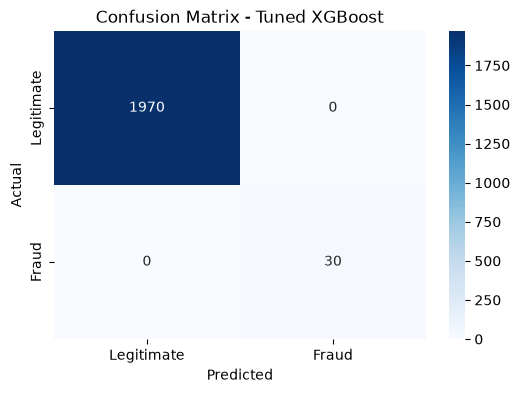

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, tuned_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Legitimate', 'Fraud'],
    yticklabels=['Legitimate', 'Fraud']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Tuned XGBoost')
plt.show()

### Access the XGBoost classifier inside your pipeline

In [88]:
xgb_classifier = tuned_xgb_model.named_steps['classifier']

print(xgb_classifier)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)


### Get the processed feature names

In [89]:
feature_names = tuned_xgb_model.named_steps['preprocessor'].get_feature_names_out()

print(feature_names)
print("Number of features:", len(feature_names))

['mun__amount' 'mun__transaction_hour' 'mun__device_trust_score'
 'mun__velocity_last_24h' 'mun__cardholder_age'
 'cat__merchant_category_Clothing' 'cat__merchant_category_Electronics'
 'cat__merchant_category_Food' 'cat__merchant_category_Grocery'
 'cat__merchant_category_Travel' 'remainder__foreign_transaction'
 'remainder__location_mismatch']
Number of features: 12


### Create the feature-importance DataFrame

In [90]:

importance = xgb_classifier.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance_df)

                               Feature  Importance
2              mun__device_trust_score    0.201026
1                mun__transaction_hour    0.194751
10      remainder__foreign_transaction    0.141399
3               mun__velocity_last_24h    0.138048
11        remainder__location_mismatch    0.124966
0                          mun__amount    0.050337
8       cat__merchant_category_Grocery    0.046186
5      cat__merchant_category_Clothing    0.035264
6   cat__merchant_category_Electronics    0.035005
9        cat__merchant_category_Travel    0.027533
4                  mun__cardholder_age    0.003214
7          cat__merchant_category_Food    0.002273


## SHAP Explainability

In [91]:
pip install shap

   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
    --------------------------------------- 0.8/41.9 MB 5.6 MB/s eta 0:00:08
   - -------------------------------------- 1.6/41.9 MB 4.4 MB/s eta 0:00:10
   -- ------------------------------------- 2.6/41.9 MB 4.4 MB/s eta 0:00:09
   --- ------------------------------------ 3.7/41.9 MB 4.6 MB/s eta 0:00:09
   ---- ----------------------------------- 5.0/41.9 MB 4.7 MB/s eta 0:00:08
   ------ --------------------------------- 6.3/41.9 MB 4.9 MB/s eta 0:00:08
   ------- -------------------------------- 7.3/41.9 MB 5.0 MB/s eta 0:00:07
   -------- ------------------------------- 8.7/41.9 MB 5.1 MB/s eta 0:00:07
   --------- ------------------------------ 9.7/41.9 MB 5.1 MB/s eta 0:00:07
   ---------- ----------------------------- 10.7/41.9 MB 5.1 MB/s eta 0:00:07
   ----------- ---------------------------- 11.5/41.9 MB 5.0 MB/s eta 0:00:07
   ------------ --------------------------- 12.8/41.9 MB 5.1 MB/s eta 0:00:06
   

In [92]:
import shap

c:\Users\hp\OneDrive\Desktop\Gen AI\python\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [93]:
print(shap.__version__)

0.52.0


In [94]:

# Get the trained XGBoost model
xgb_classifier = tuned_xgb_model.named_steps['classifier']

# Transform test data using the pipeline's preprocessor
X_test_transformed = tuned_xgb_model.named_steps['preprocessor'].transform(X_test)

# Convert sparse matrix to dense array if necessary
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_classifier)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_transformed)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (2000, 12)


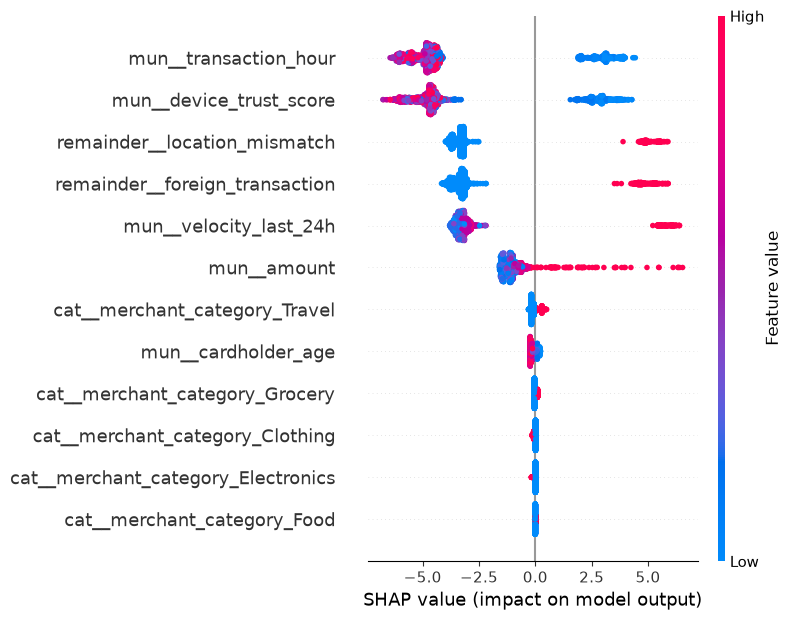

In [95]:

# # Get feature names
# feature_names = tuned_xgb_model.named_steps[
#     'preprocessor'
# ].get_feature_names_out()

# SHAP summary plot
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

## local SHAP analysis: we'll take one individual transaction and create a SHAP waterfall plot

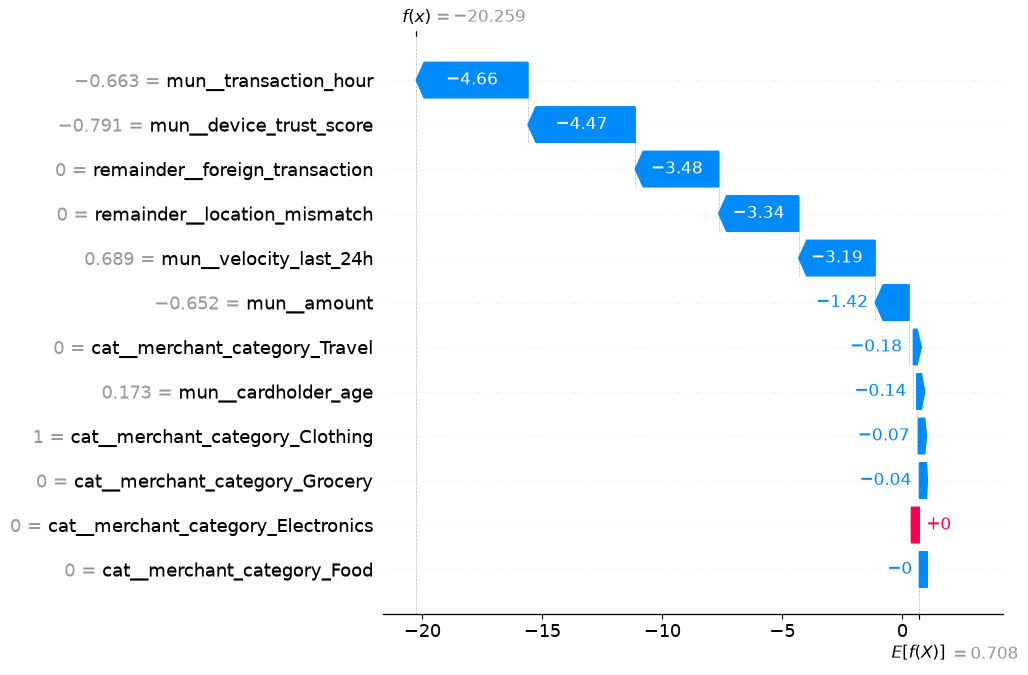

In [96]:
# Create SHAP Explanation object for the first test transaction

shap_explanation = shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_test_transformed[0],
    feature_names=feature_names
)

# Plot waterfall
shap.plots.waterfall(shap_explanation, max_display=12)

In [98]:
## SHAP for Fraud Transaction
fraud_indices=Y_test[Y_test == 1].index
print(fraud_indices[10])

4969


In [99]:
fraud_index=fraud_indices[0]
print(fraud_index)

7656


In [100]:
fraud_position=Y_test.index.get_loc(fraud_index)
print("Position:",fraud_position)

Position: 56


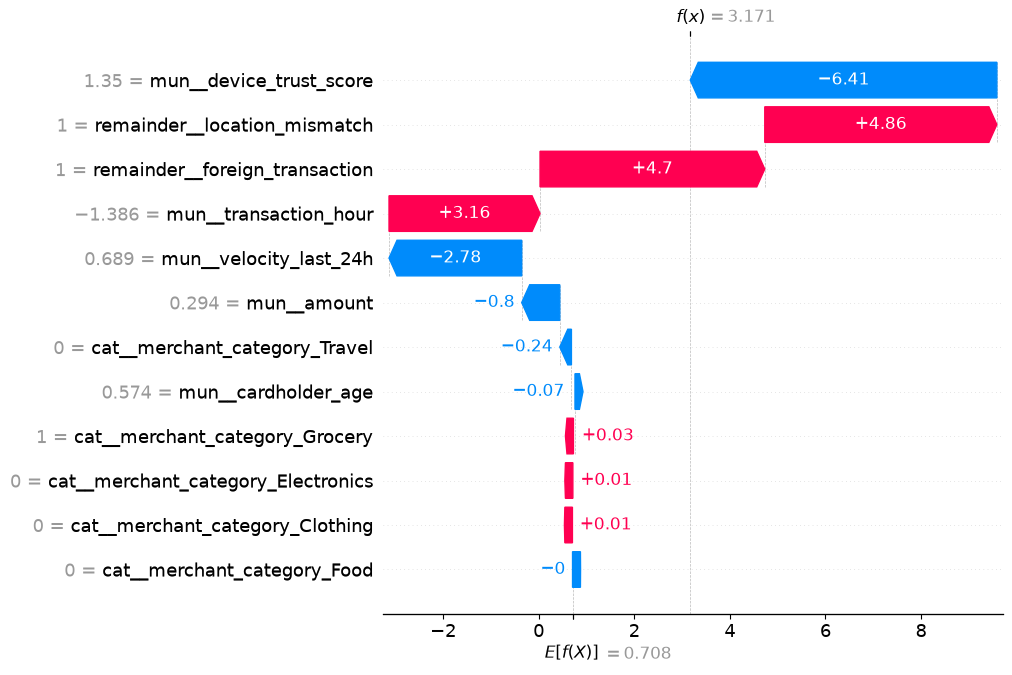

In [101]:
fraud_explaination = shap.Explanation(
    values=shap_values[fraud_position],
    base_values=explainer.expected_value,
    data=X_test_transformed[fraud_position],
    feature_names=feature_names
)

shap.plots.waterfall(
    fraud_explaination,
    max_display=12
)

## Saving the tuned model in pickle file

In [103]:
import joblib

joblib.dump(tuned_xgb_model,"fraud_detection_model.pkl")

print("Model saved sucsessfully")

Model saved sucsessfully


In [104]:
## Verifying that the saved model can actually be loaded
loaded_model=joblib.load("C:/Users/hp/OneDrive/Desktop/Fraud Detection/models/fraud_detection_model.pkl")
print("Model Loaded Successfully")

loaded_pred=loaded_model.predict(X_test)

print("Predictions match:",(loaded_pred==tuned_test_pred).all())

Model Loaded Successfully
Predictions match: True


In [106]:
loaded_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['amount','transaction_hour','merchant_category',...,'device_trust_score', 'velocity_last_24h','cardholder_age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('mun', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By 